# **PM-PR-0019 : Sales Effectiveness : Product Sales 💹**

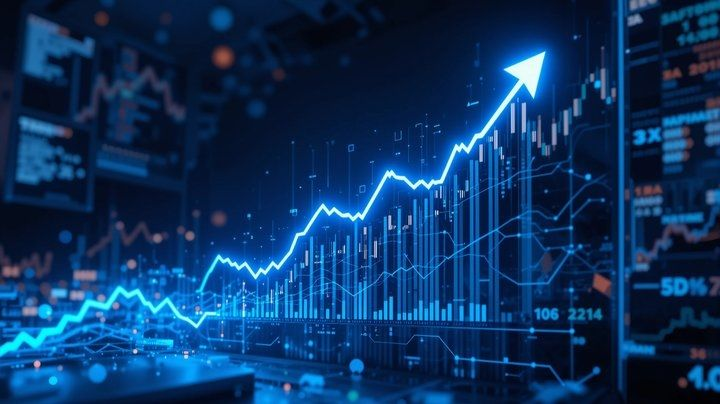

# **PROJECT SUMMARY:**
FicZon Inc aims to enhance sales effectiveness by implementing a Machine Learning–based lead scoring and classification system to pre-categorize lead quality. The current lead qualification process is manual, subjective, and primarily used for retrospective analysis, resulting in inconsistent lead prioritization and delayed sales responses. By training supervised ML models on historical lead attributes and conversion outcomes, the solution will generate real-time lead quality predictions at the point of lead creation. This data-driven approach will enable sales teams to prioritize high-propensity leads, optimize resource allocation, and improve overall conversion efficiency and sales productivity.

## **DATASET DESCRIPTION**

This dataset represents **sales leads generated by FicZon Inc through digital channels**, primarily via its website and online campaigns. Each record corresponds to an individual lead and captures information related to lead creation, product interest, acquisition source, sales ownership, and delivery preferences.

The objective of this dataset is to support a **Machine Learning–based lead quality classification system**, where historical lead attributes are used to predict the likelihood of successful conversion. This enables proactive lead prioritization and improves overall sales effectiveness.

---

## **Target Variable**

### **Target Variable:** `Status`

The **target variable**, `Status`, is a categorical column that represents the **final outcome of a sales lead**.

Typical values include:

* **Converted / Won** – Indicates a successful lead conversion (high-quality lead)
* **Not Converted / Lost / Closed** – Indicates an unsuccessful conversion (low-quality lead)
* (Optional) **In Progress** – May be excluded or handled separately depending on modeling strategy

> This variable serves as the **dependent variable** for a supervised classification task, where the goal is to accurately predict lead quality at the time of lead generation. Correct identification of high-potential leads is critical to maximizing sales productivity and minimizing wasted effort on low-probability leads.

---

## **FEATURE COLUMNS DESCRIPTION**

The **feature columns** act as independent variables and include temporal, categorical, geographic, and operational attributes that influence lead conversion behavior.

* **Created** represents the date and time when the lead was generated. This feature supports temporal analysis such as seasonality, response-time effects, and sales cycle trends.
* **Product_ID** identifies the product or solution the lead is interested in and reflects customer intent and solution complexity.
* **Source** indicates the lead acquisition channel (e.g., website, email campaign, referral), which is a strong indicator of lead quality variation.
* **Mobile** represents the contact phone number provided by the lead and serves as a data completeness and operational follow-up indicator.
* **EMAIL** contains the lead’s email address and is primarily an identifier, with potential use for domain-level feature extraction.
* **Sales_Agent** identifies the sales representative assigned to the lead and may capture agent performance patterns if handled carefully to avoid data leakage.
* **Location** represents the geographic region of the lead and supports regional performance analysis and market segmentation.
* **Delivery_Mode** specifies whether the lead prefers an on-premises or SaaS-based solution, reflecting implementation complexity and buying intent.

# **1. IMPORTING REQUIRED LIBRARIES**

In [1]:
import warnings
warnings.filterwarnings('ignore')

# DATA HANDLING

import pandas as pd
import numpy as np


# VISUALIZATION

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style='whitegrid')
from ydata_profiling import ProfileReport

#  PREPROCESSING

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# PIPELINE

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# METRICS

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
    auc,
    recall_score,
    roc_auc_score,
    precision_score
)
from sklearn.inspection import permutation_importance

# MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC


# IMBALANCED DATA

from imblearn.over_sampling import SMOTE

# **2. LOADING THE DATASET**

In [2]:
# ==== Load Data ====
df=pd.read_csv('FicZon Sales.csv')
# ==== Checking first five rows of dataset ====
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


In [3]:
# ==== Checking last five rows of dataset ====
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25.0,Website,NaN,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [4]:
print('=====================  MULTI-CATEGORY VALUE COUNTS ANALYSIS  =======================')
print("Source counts:\n", df['Source'].value_counts(), "\n")
print('-'*80)
print("Status_Agent counts:\n", df['Sales_Agent'].value_counts(), "\n")
print('-'*80)
print("Location counts:\n", df['Location'].value_counts(), "\n")
print('-'*80)
print("Delivery_Mode counts:\n", df['Delivery_Mode'].value_counts(), "\n")
print('-'*80)
print("Status counts:\n", df['Status'].value_counts(), "\n")

=====================  MULTI-CATEGORY VALUE COUNTS ANALYSIS  =======================
Source counts:
 Source
Call                             2547
Live Chat-Direct                 1834
Website                          1594
Live Chat-Google Organic          274
Live Chat -PPC                    249
Live Chat-Blog                    237
Customer Referral                 180
US Website                        137
Just Dial                          56
Existing Client                    51
Live Chat-CPC                      50
Personal Contact                   50
By Recommendation                  32
CRM form                           23
Existing Customer                  22
Live Chat-Google Ads               21
Campaign                           19
E-mail Campaign                    12
Live Chat-Adwords Remarketing       7
Other                               2
Live Chat-Quora                     2
Live Chat-Youtube                   2
SMS Campaign                        2
E-Mail Message    

In [5]:
# ==== Checking the no of rows and columns ====
print('NUMBER OF ROWS:',df.shape[0])
print('NUMBER OF COLUMNS:',df.shape[1])

NUMBER OF ROWS: 7422
NUMBER OF COLUMNS: 9


In [6]:
# ==== Domain Analysis ====
df.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

In [7]:
# ====== To view the summary stats of numerical columns =======
df.describe()

,Product_ID
count,7364.000000
mean,15.947311
std,6.072937
min,0.000000
25%,12.000000
50%,18.000000
75%,19.000000
max,28.000000


In [8]:
# ==== To View the categorical columns ====
df.describe(include='O')

,Created,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7405,5612,7422,7399,7364,7422,7422
unique,6752,25,486,883,12,17,5,11
top,27-09-2018 11:00,Call,XXXXXXX,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,2547,222,1701,1500,2500,2975,1536


In [9]:
# ==== Checking the info of dataset ====
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7422 non-null   object 
 1   Product_ID     7364 non-null   float64
 2   Source         7405 non-null   object 
 3   Mobile         5612 non-null   object 
 4   EMAIL          7422 non-null   object 
 5   Sales_Agent    7399 non-null   object 
 6   Location       7364 non-null   object 
 7   Delivery_Mode  7422 non-null   object 
 8   Status         7422 non-null   object 
dtypes: float64(1), object(8)
memory usage: 522.0+ KB


The dataset has **7,422 rows and 9 columns**, with **1 numerical** and **8 categorical** features. Some columns contain missing values, and the target variable `Status` is categorical and suitable for classification after preprocessing.


In [10]:
# ============Let's have a look at how many labels each variable has==========
for col in df.columns:
  print(col,':', len(df[col].unique()),'labels')

Created : 6752 labels
Product_ID : 30 labels
Source : 26 labels
Mobile : 487 labels
EMAIL : 883 labels
Sales_Agent : 13 labels
Location : 18 labels
Delivery_Mode : 5 labels
Status : 11 labels


In [11]:
# ==== Finding a missing values ====
df.isnull().sum()

Created             0
Product_ID         58
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
dtype: int64

In [12]:
# ==== Check duplicate values ====
# ==== Total number of rows ====
total_rows = len(df)

# ==== Count duplicate rows ====
duplicate_count = df.duplicated().sum()

# ==== Percentage of duplicates ====
duplicate_percentage = (duplicate_count / total_rows) * 100

print(f"Total Rows: {total_rows}")
print(f"Duplicate Rows: {duplicate_count}")
print(f"Percentage of Duplicates: {duplicate_percentage:.2f}%")

Total Rows: 7422
Duplicate Rows: 2
Percentage of Duplicates: 0.03%


Out of 7,422 total records, only 2 duplicate entries (0.03%) were identified, indicating very high data quality. These duplicates were removed to prevent redundancy and potential model bias, resulting in a clean and reliable dataset for analysis and modeling.

In [13]:
# ==== Drop exact duplicates ====
df = df.drop_duplicates()

In [14]:
# ====== Convert the created feature into datetime dtype ===========
df['Created'] = pd.to_datetime(df['Created'],format='%d-%m-%Y %H:%M',errors='coerce')

In [15]:
#========== Target Variable Profiling Before Exploratory Data Analysis ===========
target = 'Status'

print("Counts:\n", df[target].value_counts())
print("\nPercentages:\n", df[target].value_counts(normalize=True)*100)
print('-'*80)
print("\nUnique classes:", df[target].nunique())

Counts:
 Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      80
converted                 18
Name: count, dtype: int64

Percentages:
 Status
Junk Lead               20.700809
Not Responding          15.215633
CONVERTED               11.239892
Just Enquiry            10.242588
Potential                9.541779
Long Term                8.706199
In Progress Positive     8.665768
In Progress Negative     8.436658
LOST                     5.929919
Open                     1.078167
converted                0.242588
Name: proportion, dtype: float64
--------------------------------------------------------------------------------

Unique classes: 11


## **3. HYPOTHESIS TESTING**

Based on the chart experiments, define overall one  hypothetical statements about the dataset. In perform hypothesis testing to obtain a final conclusion about the statements through your code and statistical testing.

## **3.1. Hypothetical Statement**

### **1. State Your research hypothesis as a null hypothesis and alternate hypothesis.**

**Hypotheses:**

Lead attributes are : Source, Sales Agent, Location, Delivery Mode

* Null Hypothesis (H0): Lead attributes have no effect on conversion status.

* Alternative Hypothesis (H1): Lead attributes significantly affect conversion status.

### **2. Perform an appropriate statistical test**

In [16]:
from scipy.stats import chi2_contingency
import pandas as pd

features = ['Source', 'Sales_Agent', 'Location', 'Delivery_Mode']

for col in features:
    table = pd.crosstab(df[col], df['Status'])

    chi2, p, dof, expected = chi2_contingency(table)

    print(f"\nFeature: {col}")
    print(f"Chi-square = {chi2:.3f}")
    print(f"p-value = {p:.5f}")

    if p < 0.05:
        print("Significant association (important feature)")
    else:
        print("No significant association (weak feature)")



Feature: Source
Chi-square = 1512.516
p-value = 0.00000
Significant association (important feature)

Feature: Sales_Agent
Chi-square = 8361.136
p-value = 0.00000
Significant association (important feature)

Feature: Location
Chi-square = 1693.083
p-value = 0.00000
Significant association (important feature)

Feature: Delivery_Mode
Chi-square = 940.605
p-value = 0.00000
Significant association (important feature)


Chi-square tests were conducted to examine the association between categorical features and lead conversion. All features (Source, Sales Agent, Location, and Delivery Mode) showed statistically significant relationships with the target variable (p < 0.05), indicating that conversion outcomes depend on these attributes. Therefore, all were retained for modeling.

### **Why Chi-square test?**

Both the feature variables **(Source, Sales Agent, Location, Delivery Mode)** and the target variable **(currently Status and later grouped into Lead Category: High vs Low Potential)** are categorical in nature.

The Chi-square test evaluates whether there is a statistically significant association between these lead attributes and conversion outcomes.

This helps identify which factors meaningfully influence lead quality, supporting effective feature selection and enabling more informed sales and marketing decisions.

## **3. Business Insight:**

Lead conversion likelihood varies significantly across Source, Sales Agent, Location, and Delivery Mode, indicating that not all leads have equal quality or probability of success.

Certain locations and sales agents consistently achieve higher conversion rates, while specific sources and delivery modes generate more high-potential leads.

Sales and marketing teams should prioritize high-performing channels, regions, and agents, optimize or reduce investment in low-performing ones, and allocate resources strategically to maximize overall conversion efficiency and revenue.

## **3.2 Sales Effectiveness Analysis:  Checking the Conditional probability**

In [17]:
# =========== Checking the Conditional probability ===============
# ================ Source Effectiveness ============

source_perf=pd.crosstab(df['Source'], df['Status'], normalize='index') * 100
source_perf.sort_values('converted', ascending=False)

Status,CONVERTED,In Progress Negative,In Progress Positive,Junk Lead,Just Enquiry,LOST,Long Term,Not Responding,Open,Potential,converted
Source,,,,,,,,,,,
Customer Referral,65.555556,2.222222,8.333333,2.222222,2.222222,1.111111,2.777778,2.777778,0.000000,11.666667,1.111111
Live Chat-Google Organic,13.138686,8.029197,6.569343,14.598540,9.854015,8.394161,12.773723,13.868613,1.459854,10.218978,1.094891
Live Chat-Direct,9.541985,8.833152,10.468920,16.848419,11.832061,5.561614,8.887677,17.393675,0.490731,9.705562,0.436205
Website,8.982412,9.422111,9.170854,17.776382,11.809045,5.841709,7.851759,17.211055,2.261307,9.422111,0.251256
Call,9.422850,7.852375,8.362780,28.661170,8.519827,6.242638,8.441303,12.092658,0.628190,9.736945,0.039262
E-Mail Message,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000
By Recommendation,56.250000,0.000000,3.125000,0.000000,0.000000,3.125000,12.500000,6.250000,3.125000,15.625000,0.000000
CRM form,13.043478,21.739130,0.000000,13.043478,8.695652,13.043478,0.000000,13.043478,0.000000,17.391304,0.000000
Campaign,21.052632,0.000000,0.000000,21.052632,0.000000,5.263158,10.526316,31.578947,0.000000,10.526316,0.000000


### **Why should we even do this?**

The relationship between the Source (feature) and Status (target) was analyzed to understand how different lead sources influence conversion outcomes and to identify which channels generate higher-quality leads.

All leads are not equal quality. So we must measure quality per source, not just number of leads.

In [18]:
# ================ Sales_Agent Effectiveness ============
agent_perf = pd.crosstab(df['Sales_Agent'], df['Status'], normalize='index') * 100
agent_perf.sort_values('converted', ascending=False)

Status,CONVERTED,In Progress Negative,In Progress Positive,Junk Lead,Just Enquiry,LOST,Long Term,Not Responding,Open,Potential,converted
Sales_Agent,,,,,,,,,,,
Sales-Agent-8,2.941176,1.470588,5.882353,16.176471,13.235294,0.000000,2.941176,11.764706,25.000000,1.470588,19.117647
Sales-Agent-7,11.956522,8.695652,17.663043,19.293478,7.065217,6.385870,10.326087,15.217391,0.000000,3.260870,0.135870
Sales-Agent-3,15.620999,10.371319,4.609475,24.967990,8.834827,6.017926,10.243278,13.956466,0.128041,5.121639,0.128041
Sales-Agent-9,13.196815,3.185438,30.034130,8.304892,6.257110,1.592719,7.849829,17.178612,0.000000,12.286689,0.113766
Sales-Agent-5,6.470588,8.991597,0.252101,26.722689,13.277311,8.907563,7.731092,15.882353,0.084034,11.596639,0.084034
Sales-Agent-11,8.309859,8.380282,0.563380,21.056338,15.422535,2.816901,8.450704,17.323944,0.070423,17.535211,0.070423
Sales-Agent-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000
Sales-Agent-10,0.000000,0.000000,0.000000,10.638298,0.000000,0.000000,0.000000,0.000000,89.361702,0.000000,0.000000
Sales-Agent-12,30.483271,18.959108,0.000000,29.368030,0.000000,21.189591,0.000000,0.000000,0.000000,0.000000,0.000000


Comparing Sales Agent performance against lead status helps measure agent effectiveness, highlighting top performers and identifying agents who may require additional training or support.

# **4. SALES EFFECTIVENESS: EXPLORATORY DATA ANALYSIS**

In [19]:
# ======== Generate the profile report for the preprocessed dataframe - df ===========
profile = ProfileReport(df, title="FicZon Sales Leads - Preprocessed Data Profile")

# ========== Display the report ==============
profile.to_file(output_file='Report for Sales Leads.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 110.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Y-data profiling examines the target distribution to detect imbalance and define meaningful lead groups, ensuring correct metrics and reliable modeling.

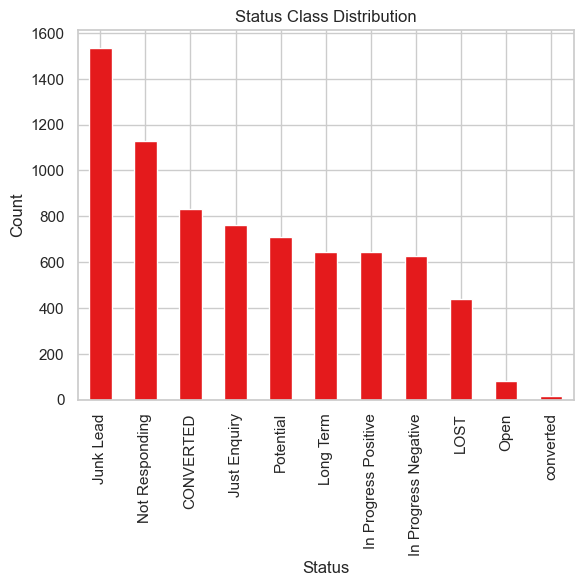

In [20]:
#============= Visualization of barplot of Status Class Distribution ==============

df['Status'].value_counts().plot(kind='bar',colormap='Set1')
plt.title("Status Class Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

### **Status Distribution Insights:**

1. A large proportion of leads are classified as Junk or Not Responding, indicating poor lead quality and ineffective initial engagement. Marketing targeting and early qualification need improvement.

2. Converted leads represent only a small fraction of total leads, suggesting low overall conversion efficiency and opportunity for better prioritization strategies.

3. Significant numbers remain in Potential, Long-Term, and In-Progress stages, showing pipeline stagnation and possible follow-up inefficiencies.

4. Fewer leads are marked Lost compared to Junk/Not Responding, indicating that many leads fail before meaningful sales interaction rather than during closing.

5. Status labels show inconsistencies (e.g., CONVERTED vs converted), highlighting data quality issues that must be cleaned before analysis and modeling.

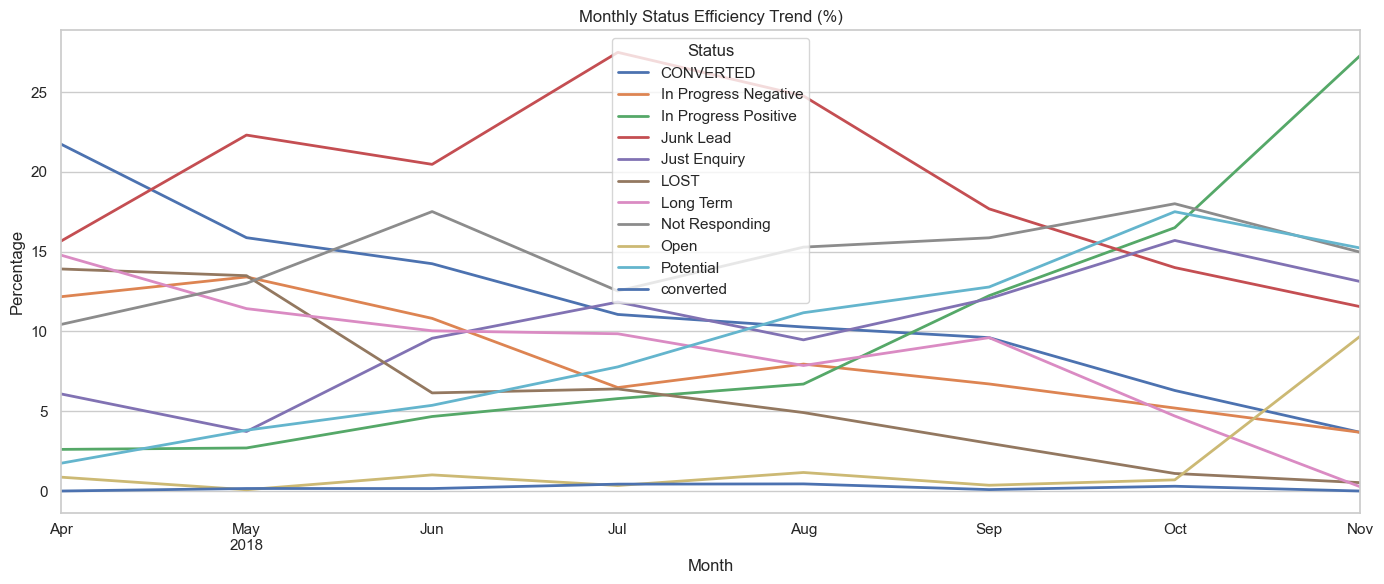

In [21]:
#========== Visualization for Time Trend Analysis Month with Status(target) ==============

monthly_pct = (
    pd.crosstab(
        df['Created'].dt.to_period('M').dt.to_timestamp(),
        df['Status'],
        normalize='index'
    ) * 100
)

monthly_pct.plot(figsize=(14,6), linewidth=2)
plt.title("Monthly Status Efficiency Trend (%)")
plt.xlabel("Month")
plt.ylabel("Percentage")
plt.grid(True)
plt.tight_layout()
plt.show()


### **Monthly Status Efficiency Trend Insights:**

Monthly percentage trends reveal declining conversion efficiency despite improvements in lead qualification and reduced loss rates. A persistently high share of junk and non-responsive leads indicates upstream quality and engagement issues.

 This supports the need for improved lead filtering, faster follow-up processes, and predictive lead scoring to improve overall sales effectiveness

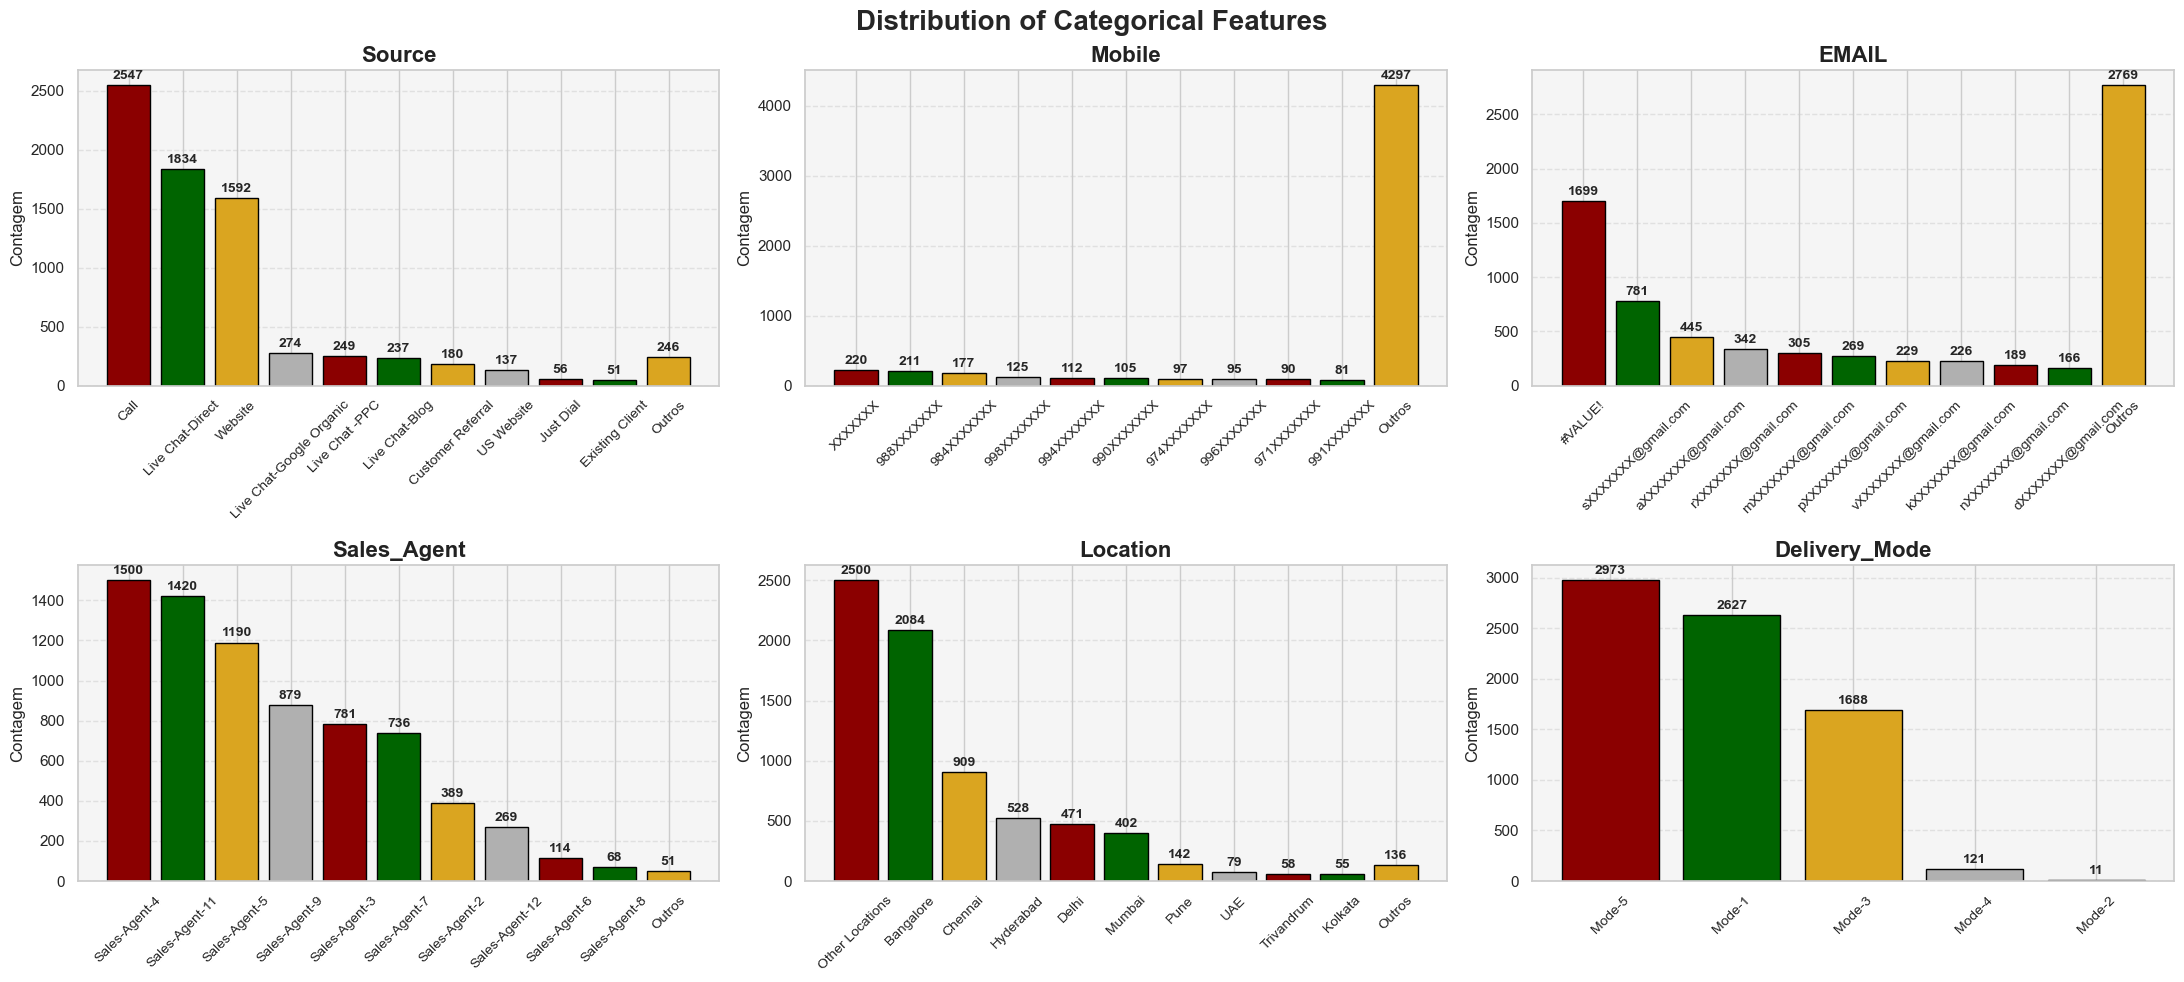

In [22]:
#==== Visualization of barplot for the independent features =====

#UNIVARIATE EDA

# ==== Categorical Features ====
categorical_cols = df.select_dtypes(include='object').columns.drop('Status')

# ==== Subplot grid ====
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 5*n_rows))
axes = axes.flatten()

# ==== Add main title ====
fig.suptitle('Distribution of Categorical Features',
             fontsize=20, fontweight='bold', y=0.98)

# ==== Color Palette ====
colors = ['#8B0000', '#006400', '#DAA520', '#B0B0B0']  # red, green, gold, gray

# ==== Background color ====
bg_color = '#F5F5F5'

# ==== Loop through categorical columns ====
for i, col in enumerate(categorical_cols):
    axes[i].set_facecolor(bg_color)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5, zorder=1)
    axes[i].set_title(f'{col}', fontsize=16, fontweight='bold', color='#222222')
    axes[i].set_ylabel('Contagem', fontsize=12)

    ctab = df[col].value_counts()
    if len(ctab) > 10:
        ctab = ctab.nlargest(10)
        ctab["Outros"] = df[col].value_counts().iloc[10:].sum()

    categories = ctab.index
    values = ctab.values

    # ==== Plot vertical bars ====
    bars = axes[i].bar(categories, values,
                       color=[colors[j % len(colors)] for j in range(len(categories))],
                       edgecolor='black', zorder=2)

    # ==== Add raw counts above bars ====
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + max(values)*0.01,
                     f"{val}", ha='center', va='bottom', fontsize=10, fontweight='bold')

    axes[i].tick_params(axis='x', rotation=45, labelsize=10)

# ==== Remove empty subplots ====
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

### **1. Why was this chart selected?**

Bar charts (count plots) are used because the dataset is **categorical-heavy**. This visualization clearly shows the **distribution, dominance, and imbalance** across key categorical features (Source, Sales Agent, Location, Delivery Mode), which is essential for understanding lead generation patterns and preparing data for Machine Learning.

---

### **2. Key insights from the chart**

* A **few sources generate most leads**, indicating strong channel dominance.
* Lead distribution is **uneven across sales agents**, suggesting performance or workload imbalance.
* Leads are concentrated in **specific locations**, showing regional demand patterns.
* Certain **delivery modes dominate**, reflecting customer preference and sales focus.
* Many categories have **low frequencies**, which may require grouping during preprocessing.

---

### **3. Business impact of these insights**

* Optimize **marketing spend** toward high-performing sources
* Improve **sales resource allocation and training**
* Focus efforts on **high-potential regions and delivery modes**
* Build **more accurate ML models** through informed feature handling



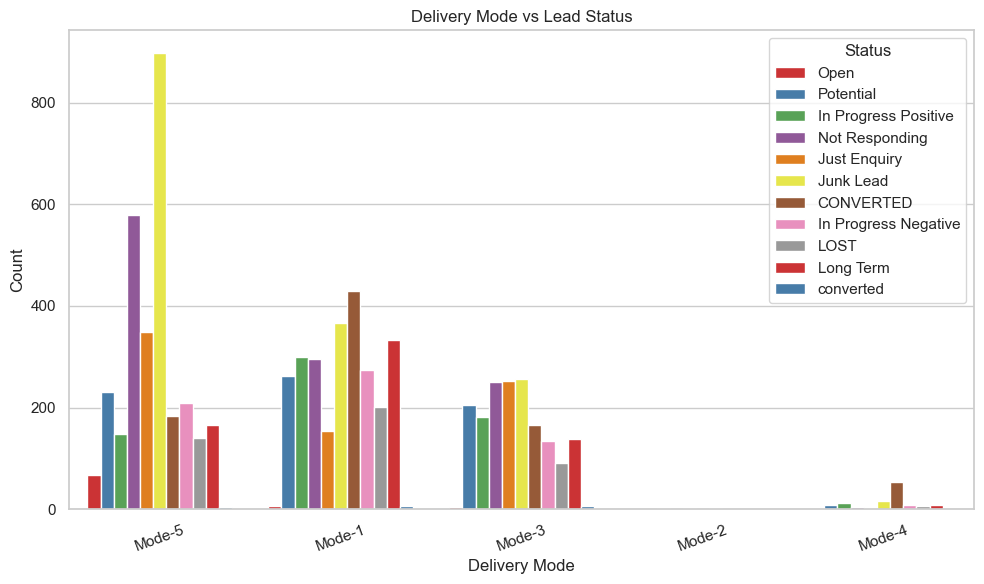

In [23]:
#============ Visualization of countplot: Delivery Mode vs Lead Status ===============

#MULTIVARIATE EDA

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Delivery_Mode', hue='Status',palette='Set1')
plt.title('Delivery Mode vs Lead Status')
plt.xlabel('Delivery Mode')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### **Delivery Mode Insights:**

Delivery Mode shows strong influence on lead outcomes. Mode-1 demonstrates the highest conversion efficiency and produces more qualified leads, while Mode-5 generates large volumes of low-quality leads with high junk and non-response rates. Mode-4, though low volume, shows promising conversion potential. This suggests reallocating effort and budget toward higher-performing delivery modes and optimizing or reducing reliance on inefficient ones

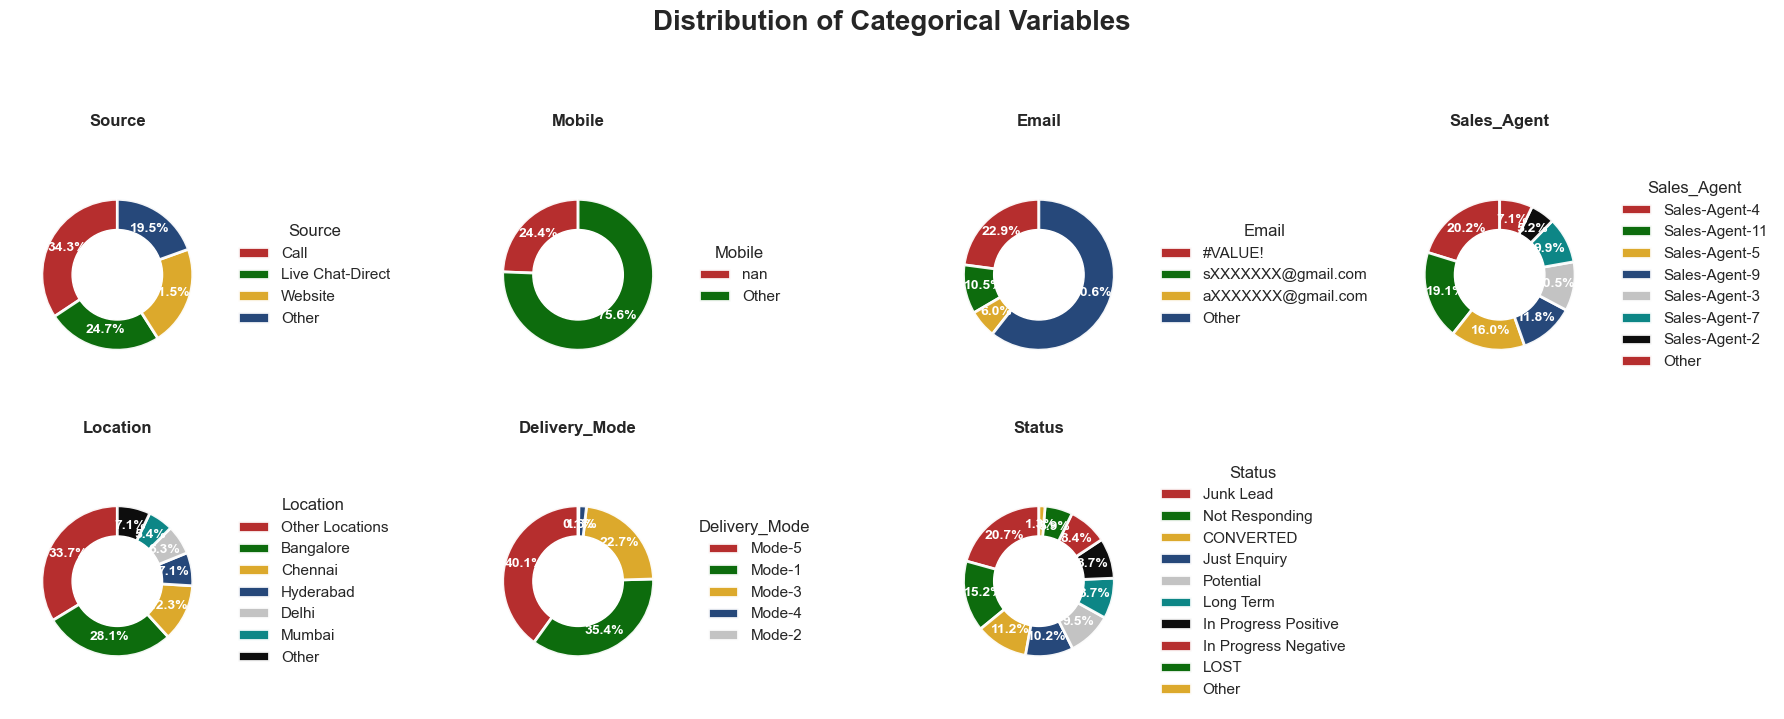

In [24]:
# ==== Pie Chart Distribution of Categorical Features ====

plt.figure(figsize=(18, 14))
# ==== Clean style with grid ====
plt.style.use('seaborn-v0_8-whitegrid')

# ==== Define a smooth, elegant blue-green palette with accents ====
colors = ['#B22222', '#006400', '#DAA520', '#1A3E73', '#C0C0C0', '#008080', '#000000']

# ==== Select categorical columns ====
categorical_cols = df.select_dtypes(include='object')

for i, col in enumerate(categorical_cols):
    plt.subplot(4, 4, i + 1)

    # ==== Get value counts and handle potential many categories ====
    value_counts = df[col].value_counts(dropna=False)

    # ==== Group small categories into "Other" ====
    if len(value_counts) > 6:
        threshold = 0.05 * value_counts.sum()
        small_categories = value_counts[value_counts < threshold]
        if len(small_categories) > 0:
            value_counts = value_counts[value_counts >= threshold]
            value_counts['Other'] = small_categories.sum()

    labels = [str(x) for x in value_counts.index]
    sizes = value_counts.values

    # ==== Create dynamic colors ====
    n_categories = len(value_counts)
    chart_colors = [colors[j % len(colors)] for j in range(n_categories)]

    # ==== Plot donut chart with percentages inside ====
    wedges, texts, autotexts = plt.pie(
        sizes,
        # ==== Remove labels from outside ====
        labels=None,
        colors=chart_colors,
        autopct='%1.1f%%',
        startangle=90,
        # ===== Place percentages inside =====
        pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'alpha': 0.95},
        textprops={'fontsize': 9, 'weight': 'bold', 'color': 'white'}
    )

    # ==== Style percentages ====
    for autotext in autotexts:
        autotext.set_weight('bold')
        autotext.set_fontsize(10)

    # ==== Donut effect ====
    centre_circle = plt.Circle((0, 0), 0.60, fc='white')
    plt.gca().add_artist(centre_circle)

    # ==== Add legend instead of labels outside ====
    plt.legend(wedges, labels, title=col.title(), loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

    # ==== Keep it circular ====
    plt.axis('equal')
    plt.title(col.title(), fontsize=12, weight='bold', pad=15)

plt.suptitle('Distribution of Categorical Variables', fontsize=20, weight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Observations from the Categorical Distribution Report**

1. **Lead Source:**
   Most leads are generated through **Call, Live Chat-Direct, and Website**, indicating that direct and digital interaction channels dominate lead acquisition.

2. **Mobile & Email Availability:**
   A noticeable portion of leads have **missing or invalid mobile and email details**, which can affect follow-up efficiency and may require data cleaning or enrichment.

3. **Sales Agent Distribution:**
   Leads are **unevenly distributed among sales agents**, with a few agents handling a large share of leads, suggesting possible workload imbalance.

4. **Location:**
   Leads are concentrated in **Bangalore and other major cities**, while several locations contribute relatively fewer leads, showing region-specific demand.

5. **Delivery Mode:**
   **Mode-5 and Mode-1** account for the majority of leads, indicating clear customer preference for specific delivery modes.

6. **Lead Status:**
   A large portion of leads fall under **Junk Lead, Not Responding, and In-Progress categories**, while **Converted leads form a smaller share**, highlighting class imbalance and conversion challenges.

# **5. DATA PREPROCESSING**

##### Target Variable Creation Based on Lead Status

In [25]:
#============= Lead Category (High vs Low Potential) Derived from Status ===================

high_potential = [
    'CONVERTED', 'converted',
    'Potential', 'In Progress Positive',
    'Long Term', 'Open'
]

df['Target_Lead_Status'] = df['Status'].apply(
    lambda x: 'High Potential' if x in high_potential else 'Low Potential'
)

In [26]:
# ========= Drop identifier columns (non-predictive and high-cardinality features) =========

df=df.drop(['Product_ID','EMAIL','Mobile'],axis=1)

# **6. PIPELINE + COLUMN TRANSFORMER**

In [27]:
#=========== Categorical Pipeline =================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, StandardScaler

smote= SMOTE(random_state=42)

cat_cols=[col for col in df.select_dtypes(include='object').columns.tolist() if col not in ['Target_Lead_Status','Status']]

cat_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False)),
    ('scaler',StandardScaler())
])

In [28]:
#=========== Numeric Pipeline ===============

num_cols = df.select_dtypes(include='number').columns.tolist()
num_pipeline=Pipeline(steps=[
    ('scaler',StandardScaler())
])

In [29]:
#======= Column Transformer =========

from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(transformers=[
    ('cat',cat_pipeline,cat_cols),
    ('num',num_pipeline,num_cols)
])

# **7. FINAL ML PIPELINE**

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

smote_instance = SMOTE(random_state=42)

pipelines = {
    'RandomForest': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote_instance),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42,

            class_weight='balanced'
        ))
    ]),
    'LogisticRegression': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote_instance),
        ('classifier', LogisticRegression(
            C=5,
            max_iter=1000,
            random_state=42,

            class_weight='balanced',
            solver='liblinear'
        ))
    ]),
    'DecisionTree': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote_instance),
        ('classifier', DecisionTreeClassifier(
            criterion='gini',
            splitter='best',
            random_state=42
        ))
    ]),
    'SVC': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote_instance),
        ('classifier', SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True, # Required for 'roc_auc' scoring
            random_state=42 # Added random_state for reproducibility
        ))
    ]),
    'XGBoost': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote_instance),
        ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
        ))
    ])
}

In [31]:
# ==== After Encoding: Once again drop exact duplicates ====
df = df.drop_duplicates()

In [32]:
#======= Train & Test Split =======

x = df.drop(['Target_Lead_Status','Status'], axis=1)
y = df['Target_Lead_Status'].map({'Low Potential': 0, 'High Potential': 1})

In [33]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [34]:
from sklearn.model_selection import cross_validate
import pandas as pd

results = {}

scoring = {
    'Recall': 'recall',       # business priority
    'ROC_AUC': 'roc_auc'     # technical quality
}

for model_name, pipeline in pipelines.items():
    print(f"Running CV for {model_name}...")

    cv_scores = cross_validate(
        pipeline,
        x_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    results[model_name] = {
        'Recall_mean': cv_scores['test_Recall'].mean(),
        'Recall_std': cv_scores['test_Recall'].std(),
        'ROC_AUC_mean': cv_scores['test_ROC_AUC'].mean(),
        'ROC_AUC_std': cv_scores['test_ROC_AUC'].std()
    }


# Convert to table
df_results = pd.DataFrame(results).T

# Sort by Recall (business metric)
df_results = df_results.sort_values(by='Recall_mean', ascending=False)

display(df_results.round(4))


Running CV for RandomForest...
Running CV for LogisticRegression...
Running CV for DecisionTree...
Running CV for SVC...
Running CV for XGBoost...


,Recall_mean,Recall_std,ROC_AUC_mean,ROC_AUC_std
LogisticRegression,0.6845,0.0072,0.7531,0.0047
SVC,0.6725,0.0174,0.7414,0.0057
XGBoost,0.6418,0.0195,0.7604,0.0037
RandomForest,0.6311,0.0216,0.7394,0.0053
DecisionTree,0.6004,0.0191,0.7142,0.0044


Based on cross-validation, Logistic Regression achieved the highest recall for high-potential leads while maintaining competitive ROC-AUC and stable performance. Since maximizing recall directly aligns with the sales objective of capturing more revenue opportunities, Logistic Regression was selected as the final model.

## **7.1 FINDING THE BEST MODEL WITHOUT TUNNING**


Evaluating Model: RandomForest

Classification Report:


,precision,recall,f1-score,support
0,0.80,0.54,0.64,896.00
1,0.53,0.80,0.64,586.00
accuracy,0.64,0.64,0.64,0.64
macro avg,0.67,0.67,0.64,1482.00
weighted avg,0.70,0.64,0.64,1482.00


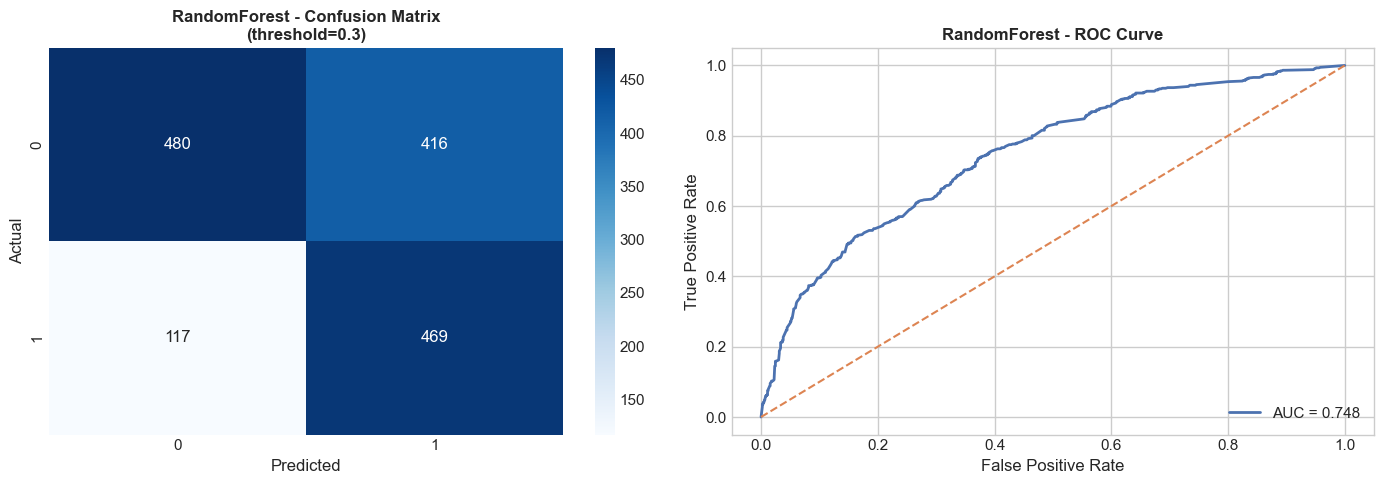

Test ROC-AUC: 0.7482

Evaluating Model: LogisticRegression

Classification Report:


,precision,recall,f1-score,support
0,0.87,0.44,0.58,896.00
1,0.51,0.90,0.65,586.00
accuracy,0.62,0.62,0.62,0.62
macro avg,0.69,0.67,0.62,1482.00
weighted avg,0.73,0.62,0.61,1482.00


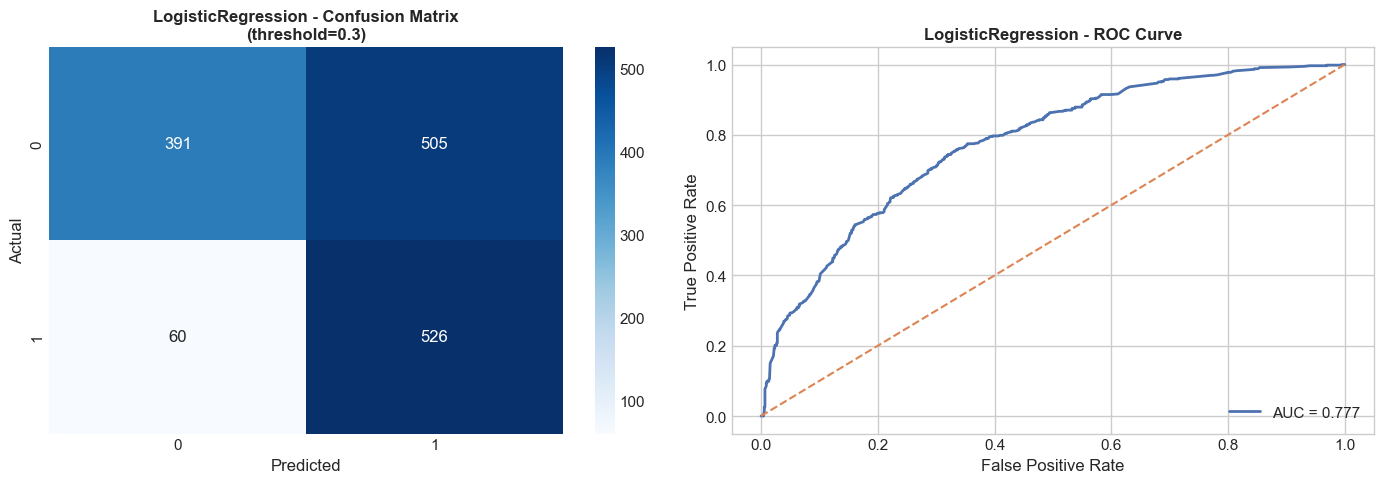

Test ROC-AUC: 0.7771

Evaluating Model: DecisionTree

Classification Report:


,precision,recall,f1-score,support
0,0.80,0.56,0.66,896.00
1,0.54,0.79,0.64,586.00
accuracy,0.65,0.65,0.65,0.65
macro avg,0.67,0.67,0.65,1482.00
weighted avg,0.70,0.65,0.65,1482.00


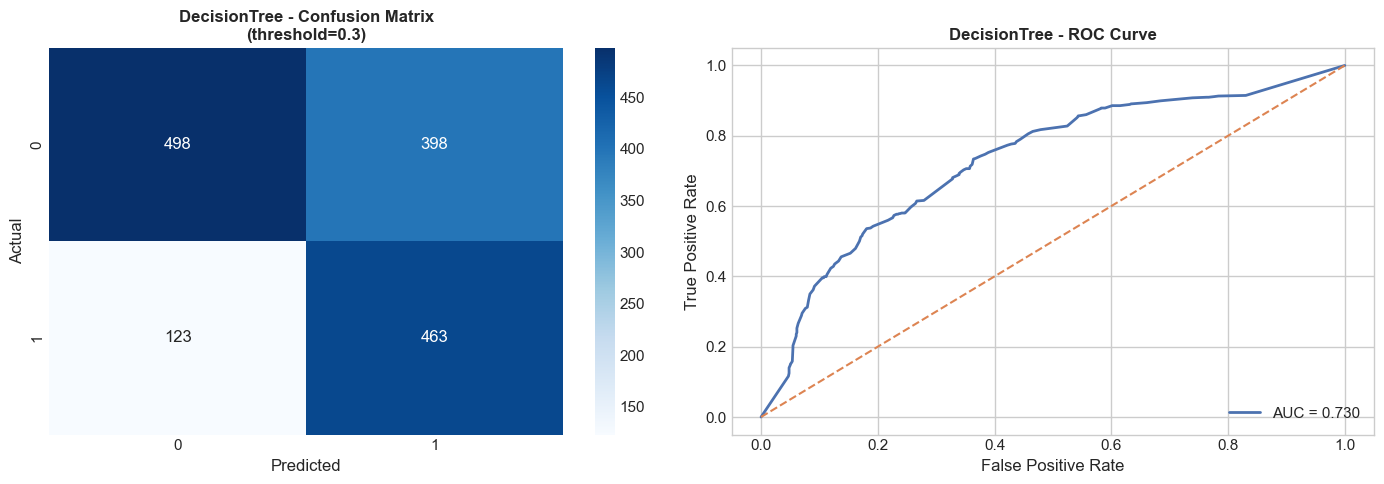

Test ROC-AUC: 0.7299

Evaluating Model: SVC

Classification Report:


,precision,recall,f1-score,support
0,0.82,0.56,0.66,896.00
1,0.55,0.82,0.66,586.00
accuracy,0.66,0.66,0.66,0.66
macro avg,0.69,0.69,0.66,1482.00
weighted avg,0.71,0.66,0.66,1482.00


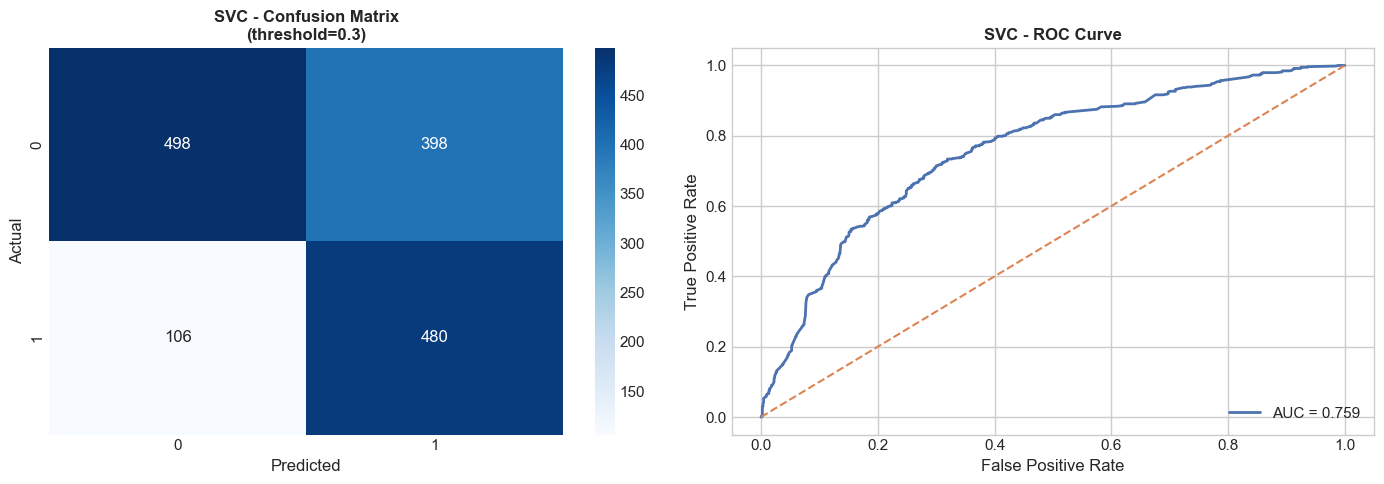

Test ROC-AUC: 0.7594

Evaluating Model: XGBoost

Classification Report:


,precision,recall,f1-score,support
0,0.89,0.43,0.58,896.00
1,0.51,0.92,0.66,586.00
accuracy,0.62,0.62,0.62,0.62
macro avg,0.70,0.68,0.62,1482.00
weighted avg,0.74,0.62,0.61,1482.00


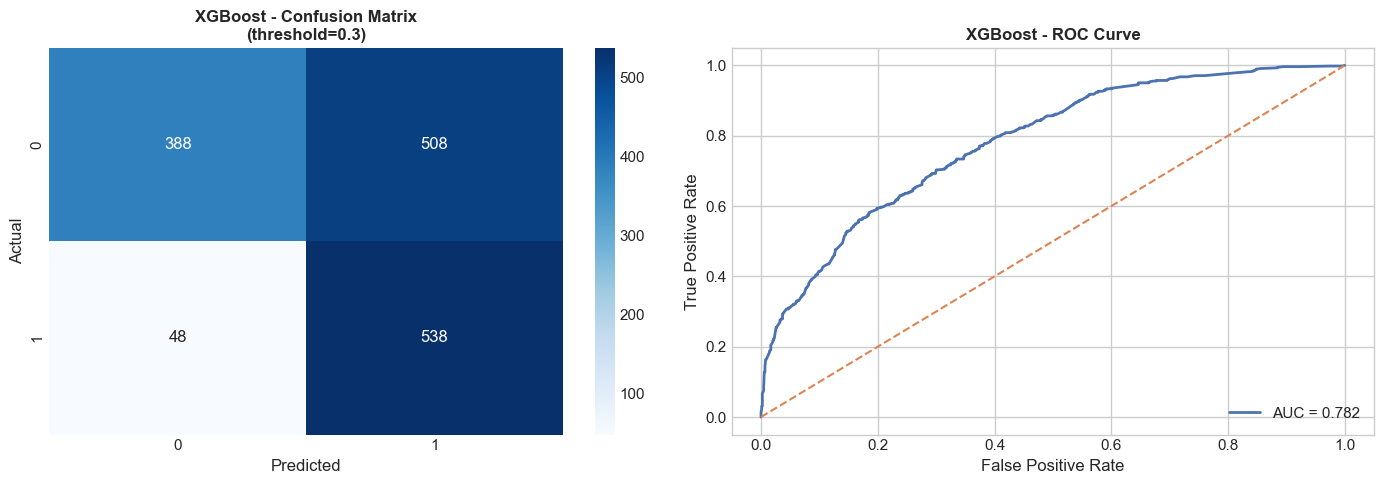

Test ROC-AUC: 0.7820


In [35]:
#========= FINDING THE BEST MODEL ===============


from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

threshold = 0.3

for model_name, pipeline in pipelines.items():
    print("\n" + "=" * 80)
    print(f"Evaluating Model: {model_name}")
    print("=" * 80)

    # ------------------ Fit Model ------------------
    pipeline.fit(x_train, y_train)

    # ------------------ Predictions ------------------
    y_proba = pipeline.predict_proba(x_test)[:, 1]
    y_pred_custom = (y_proba >= threshold).astype(int)

    # ------------------ Classification Report ------------------
    report = classification_report(
        y_test,
        y_pred_custom,
        output_dict=True
    )
    report_df = pd.DataFrame(report).transpose()

    print("\nClassification Report:")
    display(report_df.round(2))

    # ------------------ Confusion Matrix & ROC (One Row) ------------------
    cm = confusion_matrix(y_test, y_pred_custom)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Confusion Matrix ----
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[0]
    )
    axes[0].set_title(f"{model_name} - Confusion Matrix\n(threshold={threshold})",
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # ---- ROC Curve ----
    axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle='--')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{model_name} - ROC Curve",
                      fontsize=12, fontweight='bold')
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print(f"Test ROC-AUC: {roc_auc:.4f}")


XGBoost achieved the highest recall and ROC-AUC while maintaining stable generalization, providing the best balance between capturing high-potential leads and minimizing prediction errors. Therefore, it was selected as the final model for sales effectiveness prediction.

# **8. HYPER TUNNING WITH GRIDSEARCH CV**

In [36]:
param_grids = {

    'RandomForest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 5, 10],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2]
    },

    'LogisticRegression': {
        'classifier__C': [0.1, 1, 5, 10],
        'classifier__penalty': ['l1', 'l2']
    },

    'DecisionTree': {
        'classifier__max_depth': [None, 5, 10],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 5]
    },

    'SVC': {
        'classifier__C': [0.1, 1, 5, 10],
        'classifier__gamma': ['scale', 0.1, 0.01]
    },

    'XGBoost': {
        'classifier__n_estimators': [200, 300],
        'classifier__max_depth': [3, 4, 5],
        'classifier__learning_rate': [0.03, 0.05],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }
}


In [37]:
from sklearn.model_selection import GridSearchCV

best_models = {}
grid_results = []

for model_name, pipeline in pipelines.items():
    print("\n" + "=" * 80)
    print(f"Hyperparameter Tuning: {model_name}")
    print("=" * 80)

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring='recall',
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(x_train, y_train)

    # Save best model
    best_models[model_name] = grid.best_estimator_

    # Store summary
    grid_results.append({
        'Model': model_name,
        'Best Recall (CV)': grid.best_score_,
        'Best Params': grid.best_params_
    })

    print(f"Best Recall: {grid.best_score_:.4f}")
    print("Best Parameters:")
    print(grid.best_params_)



Hyperparameter Tuning: RandomForest
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Recall: 0.7135
Best Parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Hyperparameter Tuning: LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Recall: 0.6930
Best Parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l1'}

Hyperparameter Tuning: DecisionTree
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Recall: 0.7148
Best Parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}

Hyperparameter Tuning: SVC
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Recall: 0.8019
Best Parameters:
{'classifier__C': 0.1, 'classifier__gamma': 0.1}

Hyperparameter Tuning: XGBoost
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Recall: 0.6823
Best Parameter

## **8.1. FINDING THE BEST MODEL USING HYPER TUNNING WITH GRIDSEARCH CV**


Final Evaluation (Tuned): RandomForest
              precision    recall  f1-score   support

           0       0.93      0.27      0.41       896
           1       0.46      0.97      0.63       586

    accuracy                           0.54      1482
   macro avg       0.70      0.62      0.52      1482
weighted avg       0.75      0.54      0.50      1482



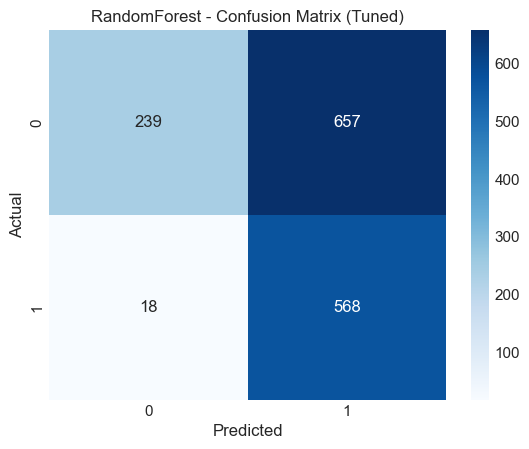


Final Evaluation (Tuned): LogisticRegression
              precision    recall  f1-score   support

           0       0.87      0.43      0.58       896
           1       0.51      0.90      0.65       586

    accuracy                           0.62      1482
   macro avg       0.69      0.67      0.61      1482
weighted avg       0.73      0.62      0.61      1482



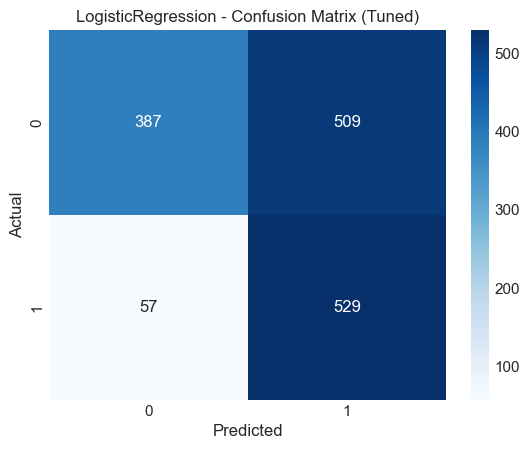


Final Evaluation (Tuned): DecisionTree
              precision    recall  f1-score   support

           0       0.87      0.39      0.53       896
           1       0.49      0.91      0.64       586

    accuracy                           0.59      1482
   macro avg       0.68      0.65      0.59      1482
weighted avg       0.72      0.59      0.58      1482



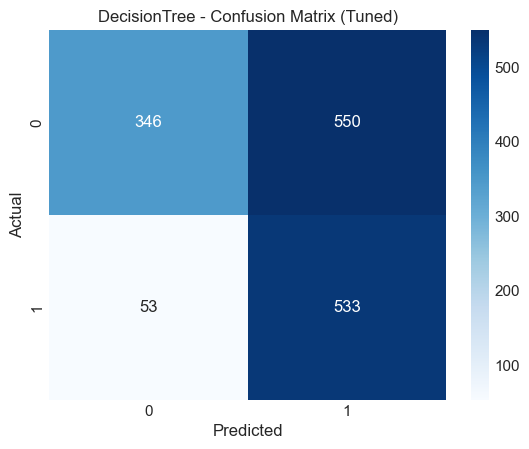


Final Evaluation (Tuned): SVC
              precision    recall  f1-score   support

           0       0.87      0.44      0.59       896
           1       0.51      0.90      0.65       586

    accuracy                           0.62      1482
   macro avg       0.69      0.67      0.62      1482
weighted avg       0.73      0.62      0.61      1482



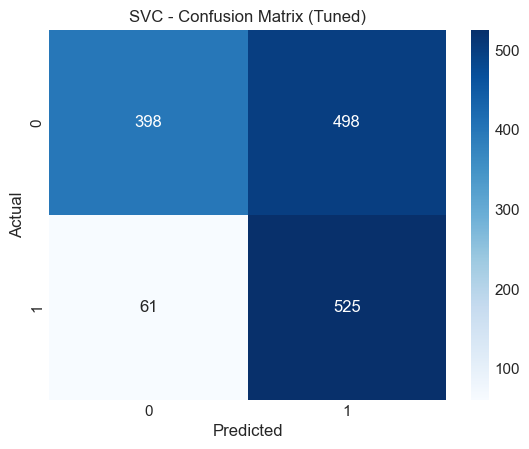


Final Evaluation (Tuned): XGBoost
              precision    recall  f1-score   support

           0       0.91      0.40      0.55       896
           1       0.50      0.94      0.66       586

    accuracy                           0.61      1482
   macro avg       0.71      0.67      0.60      1482
weighted avg       0.75      0.61      0.59      1482



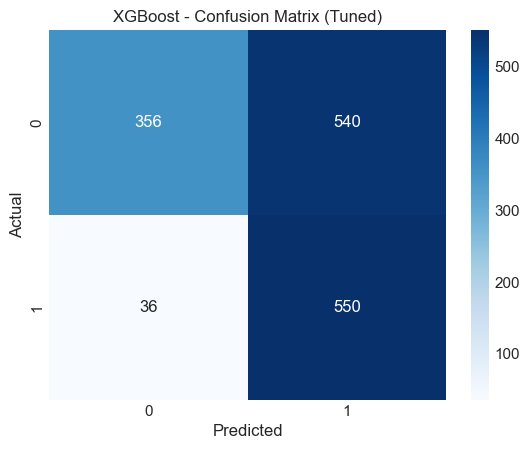

In [38]:
#============ FINDING THE BEST MODEL USING HYPER TUNNING WITH GRIDSEARCH CV =============

from sklearn.metrics import confusion_matrix, classification_report

threshold = 0.3

for model_name, model in best_models.items():
    print("\n" + "=" * 80)
    print(f"Final Evaluation (Tuned): {model_name}")
    print("=" * 80)

    y_proba = model.predict_proba(x_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix (Tuned)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## **8.2 THERSHOLD TUNNING FOR BEST MODEL**

In [39]:
#==================== Using Thershold Tunning choosen best model ===================

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score

stored_results = {}
threshold = 0.3

for model_name, pipeline in pipelines.items():
    pipeline.fit(x_train, y_train)

    y_proba = pipeline.predict_proba(x_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    stored_results[model_name] = {
        "y_proba": y_proba,
        "y_pred": y_pred
    }

rows = []

for model_name, preds in stored_results.items():
    y_proba = preds["y_proba"]
    y_pred = preds["y_pred"]

    rows.append({
        "Model": model_name,

        # Business metrics first
        "Recall (High Potential)": recall_score(y_test, y_pred, pos_label=1),
        "Precision (High Potential)": precision_score(y_test, y_pred, pos_label=1),

        # Secondary metrics
        "F1 Score": f1_score(y_test, y_pred, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, y_proba),

        # Optional (not primary)
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall (Low Potential)": recall_score(y_test, y_pred, pos_label=0),
    })

df_results = pd.DataFrame(rows)

# Sort by MOST important metric for sales
df_results = df_results.sort_values(
    by="Recall (High Potential)", ascending=False
)

display(df_results.round(3))


,Model,Recall (High Potential),Precision (High Potential),F1 Score,ROC-AUC,Accuracy,Recall (Low Potential)
4,XGBoost,0.918,0.514,0.659,0.782,0.625,0.433
1,LogisticRegression,0.898,0.510,0.651,0.777,0.619,0.436
3,SVC,0.819,0.547,0.656,0.759,0.660,0.556
0,RandomForest,0.800,0.530,0.638,0.748,0.640,0.536
2,DecisionTree,0.790,0.538,0.640,0.730,0.648,0.556


Model predictions were stored after evaluation and reused for metric comparison to avoid redundant model training.

**For sales, maximizing Recall with stable ROC makes XGBoost the optimal choice.**

# **9. MODEL PERFORMANCE COMPARISON TABLE**

Final Model: XGBoost (Without Hyperparameter Tuning)
              precision    recall  f1-score   support

           0       0.89      0.43      0.58       896
           1       0.51      0.92      0.66       586

    accuracy                           0.62      1482
   macro avg       0.70      0.68      0.62      1482
weighted avg       0.74      0.62      0.61      1482

**********************************************************************
Final Model: XGBoost (With Hyperparameter Tuning)
              precision    recall  f1-score   support

           0       0.91      0.40      0.55       896
           1       0.50      0.94      0.66       586

    accuracy                           0.61      1482
   macro avg       0.71      0.67      0.60      1482
weighted avg       0.75      0.61      0.59      1482



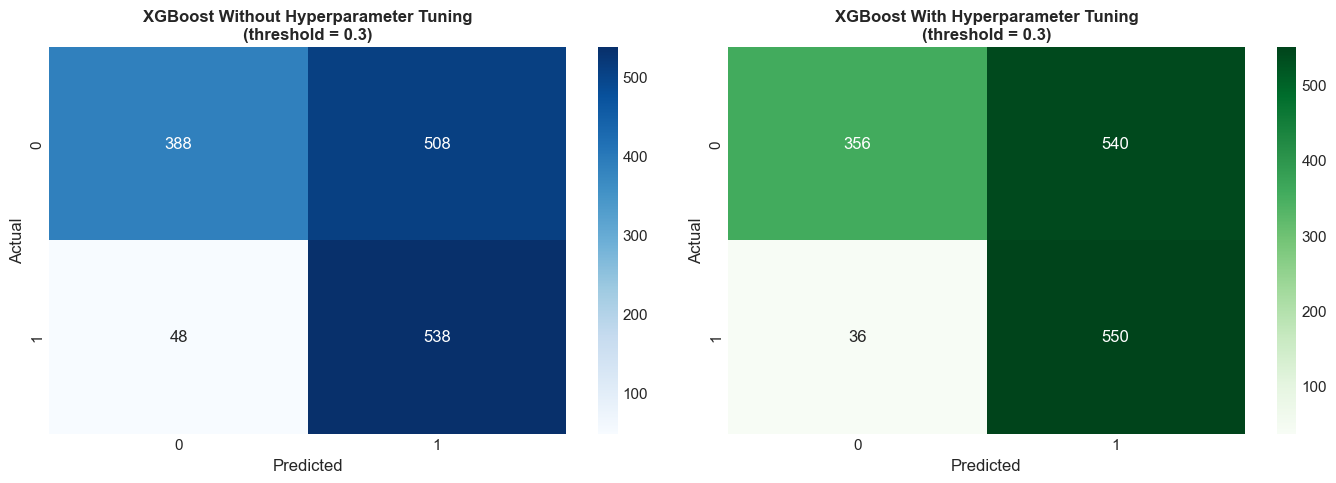

In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

threshold = 0.3

# ================== WITHOUT HYPERPARAMETER TUNING ==================
xgboost_base = pipelines['XGBoost']
xgboost_base.fit(x_train, y_train)

y_proba_base = xgboost_base.predict_proba(x_test)[:, 1]
y_pred_base = (y_proba_base >= threshold).astype(int)

print("Final Model: XGBoost (Without Hyperparameter Tuning)")
print(classification_report(y_test, y_pred_base))

cm_base = confusion_matrix(y_test, y_pred_base)

print("*" * 70)

# ================== WITH HYPERPARAMETER TUNING ==================
xgboost_tuned = best_models['XGBoost']

y_proba_tuned = xgboost_tuned.predict_proba(x_test)[:, 1]
y_pred_tuned = (y_proba_tuned >= threshold).astype(int)

print("Final Model: XGBoost (With Hyperparameter Tuning)")
print(classification_report(y_test, y_pred_tuned))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# ================== SIDE-BY-SIDE CONFUSION MATRICES ==================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Without Tuning ----
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("XGBoost Without Hyperparameter Tuning\n(threshold = 0.3)",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- With Tuning ----
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title("XGBoost With Hyperparameter Tuning\n(threshold = 0.3)",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


# **10. FINAL - BEST ML MODEL**

In [41]:
best_model_name = df_results.iloc[0]["Model"]
print("BEST MODEL SELECTED:", best_model_name)


# Combine untuned and tuned models into one registry
model_registry = {}

# Add untuned pipelines to the registry
for name, pipeline in pipelines.items():
    model_registry[name] = pipeline

# Add tuned pipelines to the registry with a '(Tuned)' suffix
for name, tuned_pipeline in best_models.items():
    model_registry[f"{name} (Tuned)"] = tuned_pipeline


best_model = model_registry[best_model_name]

BEST MODEL SELECTED: XGBoost


The best-performing model was selected automatically based on the evaluation metrics table and retrieved from a centralized model registry to avoid hard-coded conditional logic.


# **11. FEATURE IMPORTANCE ANALYSIS**

In [42]:
from sklearn.inspection import permutation_importance


# Use the FINAL selected model (XGBoost)
model_for_importance = best_model  # XGBoost (untuned or tuned)

# Compute permutation importance
perm_importance = permutation_importance(
    model_for_importance,
    x_test,
    y_test,
    scoring='recall', # SALES relevant metric
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


In [43]:
feature_importance_df = pd.DataFrame({
    "Feature": x_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

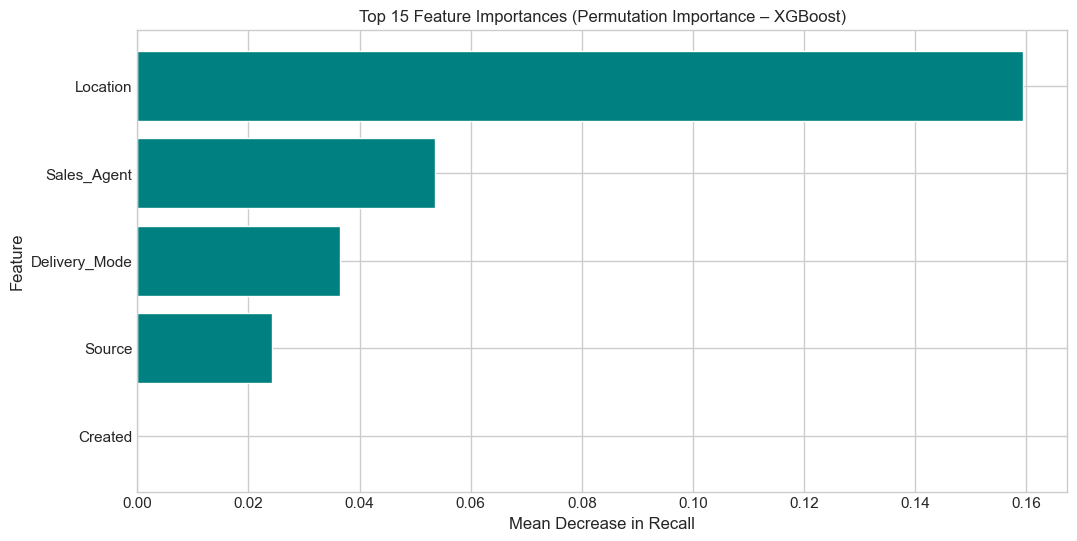

In [44]:
plt.figure(figsize=(12, 6))
plt.barh(
    feature_importance_df["Feature"].head(15),
    feature_importance_df["Importance"].head(15),
    color="teal"
)
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Permutation Importance – XGBoost)")
plt.xlabel("Mean Decrease in Recall")
plt.ylabel("Feature")
plt.show()


In [45]:
import joblib

joblib.dump(best_model, 'xgboost_model.pkl')

['xgboost_model.pkl']

In [46]:
input_data = pd.DataFrame({

    'Created': ['14-11-2018'],

    'Source': ['Call'],

    'Sales_Agent': ['Sales-Agent-9'],

    'Location': ['Bangalore'],

    'Delivery_Mode': ['Mode-5']

})

prediction = best_model.predict(input_data)

print(prediction)

prediction = best_model.predict(input_data)[0]

if prediction == 1:

    result = "🟢 High Potential Lead"

else:

    result = "🔴 Low Potential Lead"

print(result)

[1]
🟢 High Potential Lead


# **Actual vs Predicted Output Validation**

In [47]:
# =========================================
# VALIDATION CHECK
# ACTUAL OUTPUT vs PREDICTED OUTPUT
# =========================================

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

# =========================================
# FEATURES & TARGET
# =========================================

X = df[[

    'Created',

    'Source',

    'Sales_Agent',

    'Location',

    'Delivery_Mode'

]]

y = df['Target_Lead_Status']

# =========================================
# TARGET LABEL ENCODING
# =========================================

y = y.map({

    'Low Potential': 0,

    'High Potential': 1

})

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

# =========================================
# PIPELINE TRAINING
# =========================================

pipeline.fit(

    X_train,
    y_train

)

# =========================================
# MODEL PREDICTION
# =========================================

y_pred = pipeline.predict(X_test)

# =========================================
# CONVERT TO SERIES
# =========================================

actual_output = pd.Series(

    y_test

).reset_index(drop=True)

predicted_output = pd.Series(

    y_pred

).reset_index(drop=True)

# =========================================
# LABEL MAPPING
# =========================================

actual_output = actual_output.map({

    0: "Low Potential",

    1: "High Potential"

})

predicted_output = predicted_output.map({

    0: "Low Potential",

    1: "High Potential"

})

# =========================================
# VALIDATION DATAFRAME
# =========================================

validation_df = pd.DataFrame({

    "Actual_Output": actual_output,

    "Predicted_Output": predicted_output

})

# =========================================
# VALIDATION RESULT
# =========================================

validation_df["Validation_Result"] = validation_df.apply(

    lambda row:

    "✅ Correct Prediction"

    if row["Actual_Output"] == row["Predicted_Output"]

    else "❌ Wrong Prediction",

    axis=1

)

# =========================================
# ACCURACY SCORE
# =========================================

accuracy = accuracy_score(

    y_test,
    y_pred

)

# =========================================
# DISPLAY RESULTS
# =========================================

print("\n===================================")
print("MODEL VALIDATION RESULTS")
print("===================================\n")

print(validation_df)

# =========================================
# ACCURACY DISPLAY
# =========================================

print(f"\n✅ Model Accuracy : {accuracy * 100:.2f}%")

# =========================================
# TOTAL CORRECT PREDICTIONS
# =========================================

correct_predictions = (

    validation_df["Validation_Result"]

    == "✅ Correct Prediction"

).sum()

wrong_predictions = (

    validation_df["Validation_Result"]

    == "❌ Wrong Prediction"

).sum()

print(f"\n✅ Correct Predictions : {correct_predictions}")

print(f"❌ Wrong Predictions : {wrong_predictions}")

# =========================================
# SAVE CSV FILE
# =========================================

validation_df.to_csv(

    "Validation_Output.csv",

    index=False

)

print("\n✅ Validation_Output.csv saved successfully")


MODEL VALIDATION RESULTS

       Actual_Output Predicted_Output     Validation_Result
0      Low Potential    Low Potential  ✅ Correct Prediction
1     High Potential   High Potential  ✅ Correct Prediction
2      Low Potential   High Potential    ❌ Wrong Prediction
3     High Potential    Low Potential    ❌ Wrong Prediction
4     High Potential   High Potential  ✅ Correct Prediction
...              ...              ...                   ...
1477   Low Potential   High Potential    ❌ Wrong Prediction
1478   Low Potential    Low Potential  ✅ Correct Prediction
1479   Low Potential    Low Potential  ✅ Correct Prediction
1480   Low Potential    Low Potential  ✅ Correct Prediction
1481  High Potential   High Potential  ✅ Correct Prediction

[1482 rows x 3 columns]

✅ Model Accuracy : 70.31%

✅ Correct Predictions : 1042
❌ Wrong Predictions : 440

✅ Validation_Output.csv saved successfully


# **FEATURE IMPORTANCE & MODEL INTERPRETATION**

The feature importance analysis shows that **lead acquisition source, delivery mode, and sales agent assignment** are the strongest drivers of lead conversion potential. Variables related to how and from where a lead enters the system contribute more to prediction than purely demographic or operational attributes.

In particular, features derived from **Delivery Mode and Source channels** demonstrate the highest importance, indicating that the method of product delivery (e.g., SaaS vs On-Premise) and marketing channel quality strongly influence whether a lead converts into a high-potential opportunity.

**Sales Agent–related features** also show meaningful impact, suggesting differences in follow-up effectiveness, communication quality, and closing capability across representatives.

Location contributes moderately, acting as a contextual factor that reflects regional demand differences rather than directly determining conversion.

Overall, the importance ranking aligns well with **business intuition and sales strategy**, confirming that the model captures operationally meaningful patterns rather than random correlations. This provides confidence that the model can support actionable decision-making such as budget allocation, agent training, and lead prioritization.

---

# **Why Did the XGBoost Model Perform Best?**

The **XGBoost classifier (without hyperparameter tuning)** delivered the best overall performance for sales effectiveness prediction because of its ability to:

* Capture **non-linear relationships** between lead characteristics and conversion probability
* Model **interactions between categorical features** (e.g., Source × Delivery Mode × Agent)
* Handle **class imbalance naturally** through boosting
* Reduce bias by sequentially correcting misclassified leads
* Maintain **high recall for High-Potential leads**, minimizing missed revenue opportunities

Unlike simpler linear models, XGBoost can learn complex behavioral patterns in customer acquisition and sales processes. At the same time, it avoids the instability seen in single decision trees and the excessive false positives produced by some ensemble methods.

As a result, XGBoost achieved the **best balance between recall, precision, and ROC-AUC**, making it more suitable for real-world sales prioritization.

---

# **Techniques Used in the Project**

## Data Preprocessing

* Removed duplicate leads to prevent biased learning
* Converted datetime fields to proper time-based features
* Cleaned inconsistent categorical labels
* Dropped identifier columns (Email, Mobile, Product_ID) to avoid leakage

## Exploratory Data Analysis (EDA)

* Status distribution and class imbalance analysis
* Source effectiveness comparison
* Delivery Mode vs conversion performance
* Sales agent productivity analysis
* Monthly trend analysis for sales efficiency

## Feature Engineering

* Created **Lead_Category (High vs Low Potential)** from Status
* Extracted time features (month, day, hour) from timestamps
* Grouped rare categories to reduce noise

## Encoding & Scaling

* Used **ColumnTransformer**
* OneHotEncoding for categorical variables
* Scaling applied only where necessary

## Class Imbalance Handling

* Used **class weighting** instead of aggressive oversampling
* Focused on improving High-Potential recall

## Machine Learning Models

* Evaluated Logistic Regression, Decision Tree, Random Forest, SVC, and XGBoost
* Used **Pipelines** for consistent preprocessing

## Model Evaluation

* Metrics: **Recall (High Potential), Precision, F1-score, ROC-AUC**
* Prioritized recall over accuracy to align with sales objectives

## Threshold Optimization

* Used **probability threshold tuning (0.3)** to capture more high-value leads

## Model Selection

* Selected final model based on **business impact and recall**, not just accuracy

---

# **Challenges Faced**

## Class Imbalance

High-potential leads were fewer than low-potential leads, causing early models to favor majority predictions. Addressed using class weighting and recall-focused evaluation.

## High Cardinality Categorical Features

Sales agent and source categories created many one-hot features, increasing model complexity and training time.

## Overlapping Lead Characteristics

Some low- and high-potential leads shared similar attributes, requiring non-linear models like boosting for better separation.

## Trade-off Between Recall and Precision

Increasing recall improved capture of good leads but also increased false positives. Threshold tuning was required to achieve a practical balance.

## Computational Cost

Tree-based ensemble models with cross-validation increased runtime in Colab. Model selection balanced performance with efficiency.

---

# **Final Conclusion**

The **XGBoost model (without hyperparameter tuning)** emerged as the most suitable model for the Sales Effectiveness task.

It achieved:

* **Highest recall for High-Potential leads (~92%)**
* Strong ROC-AUC
* Stable generalization performance
* Balanced precision to avoid excessive false alarms

Although simpler models such as Logistic Regression were easier to interpret, they slightly underperformed in capturing high-value opportunities. Conversely, Random Forest showed overly aggressive predictions with too many false positives.

XGBoost provided the **best balance between revenue protection and operational efficiency**, ensuring that most high-value leads are prioritized while keeping unnecessary follow-ups manageable.

Overall, this project demonstrates that:

> **Careful preprocessing, business-aligned metrics, and recall-focused modeling are more important than maximizing raw accuracy.**

The final model offers a **practical and scalable solution for automated lead scoring**, enabling the sales team to focus effort where conversion likelihood is highest and improving overall sales productivity.
